# 23. Live Tutorial 2: From Minitab to Six Factors — Two Ways to Read an Effect

Every DoE practitioner eventually makes this comparison: a point-and-click
tool walks you through a factorial analysis one dialog box at a time, and
you want to know whether the same analysis, done in a few lines of Python,
gives the identical answer. Part A recreates that comparison directly —
in the style of a Minitab "DOE — Full Factorial Analysis" walkthrough —
on a small, synthetic 3-factor materials study. Part B then raises the
stakes with **real, published textbook data**: Box & Draper's 2⁶
full-factorial study (*Empirical Model-Building and Response Surfaces*,
Wiley 1987, Ch. 4) of a dyestuff process, 64 genuine experimental runs and
6 factors, analysed
first by hand (the contrast method, and Yates' classic sums-and-differences
algorithm) and then by an auto-generated
`statsmodels` formula — plus a screening tool built specifically for
designs with no replication at all: the normal-probability plot.

**Session plan**
1. From a video to Python: a 3-factor sintering study
2. Fitting the full model — and why it has zero residual degrees of freedom
3. Pareto chart and model reduction
4. Raising the stakes: Box & Draper's six-factor study
5. Computing effects by hand — contrasts and Yates' algorithm
6. The same effects, automatically — statsmodels OLS
7. Screening without replication: Pareto and normal-probability plots
8. Reading the result: what the book says

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product, combinations
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import statsmodels.graphics.gofplots as smg

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(606)

## 23.1 From a Video to Python: A 3-Factor Sintering Study

**Hot-pressing a ceramic pellet**: three process factors, response =
relative density (%TD, percent of theoretical density), 5 replicate
pellets pressed at each of the 8 corner settings.

| Factor | Low ($-1$) | High ($+1$) |
|---|---|---|
| A — Dwell time | 1 h | 3 h |
| B — Temperature | 1000°C | 1200°C |
| C — Pressure | 10 MPa | 30 MPa |

Exactly as a Minitab walkthrough would, we first record each factor's real
low/high values, then encode them to $\pm 1$ using the span-and-average
trick — this is what makes "the coefficient on A" mean the same thing
regardless of whether A is measured in hours, °C, or MPa.

In [2]:
factor_ranges = {
    'A': ('Dwell_time_h', 1.0, 3.0),
    'B': ('Temperature_C', 1000.0, 1200.0),
    'C': ('Pressure_MPa', 10.0, 30.0),
}
inputs_df = pd.DataFrame(
    [(k, lo, hi, label) for k, (label, lo, hi) in factor_ranges.items()],
    columns=['factor', 'low', 'high', 'label']
).set_index('factor')
inputs_df['average'] = (inputs_df['low'] + inputs_df['high']) / 2
inputs_df['span'] = (inputs_df['high'] - inputs_df['low']) / 2
inputs_df

,low,high,label,average,span
factor,,,,,
A,1.0,3.0,Dwell_time_h,2.0,1.0
B,1000.0,1200.0,Temperature_C,1100.0,100.0
C,10.0,30.0,Pressure_MPa,20.0,10.0


In [3]:
encoded_inputs = list(product([-1, 1], [-1, 1], [-1, 1]))
results = pd.DataFrame(encoded_inputs, columns=['A', 'B', 'C'])

# Decode coded -1/+1 back to real units -- the video's span+average trick, in reverse
for f in ['A', 'B', 'C']:
    results[inputs_df.loc[f, 'label']] = inputs_df.loc[f, 'average'] + results[f] * inputs_df.loc[f, 'span']
results

,A,B,C,Dwell_time_h,Temperature_C,Pressure_MPa
0,-1,-1,-1,1.0,1000.0,10.0
1,-1,-1,1,1.0,1000.0,30.0
2,-1,1,-1,1.0,1200.0,10.0
3,-1,1,1,1.0,1200.0,30.0
4,1,-1,-1,3.0,1000.0,10.0
5,1,-1,1,3.0,1000.0,30.0
6,1,1,-1,3.0,1200.0,10.0
7,1,1,1,3.0,1200.0,30.0


In [4]:
# True process (coded units): dwell time (A) and pressure (C) both raise density,
# temperature (B) barely matters in this range, and there's a genuine A:C synergy
# (longer dwell matters more when pressure is also high) -- everything else is noise.
A, B, C = results['A'], results['B'], results['C']
true_density = 92.0 + 3.5*A + 0.3*B + 2.0*C + 1.2*A*C

n_reps = 5
Y = true_density.values[:, None] + rng.normal(0, 0.3, size=(len(results), n_reps))
for i in range(n_reps):
    results[f'Y{i+1}'] = Y[:, i].round(2)

results['y'] = results[[f'Y{i+1}' for i in range(n_reps)]].mean(axis=1)
results['s'] = results[[f'Y{i+1}' for i in range(n_reps)]].std(axis=1)
results[['A', 'B', 'C', 'Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'y', 's']]

,A,B,C,Y1,Y2,Y3,Y4,Y5,y,s
0,-1,-1,-1,87.48,87.89,87.51,87.69,87.62,87.638,0.164225
1,-1,-1,1,89.22,88.57,89.37,89.18,88.60,88.988,0.374793
2,-1,1,-1,87.79,87.89,88.56,88.45,87.97,88.132,0.348597
3,-1,1,1,89.41,89.29,89.31,89.39,89.43,89.366,0.062290
4,1,-1,-1,92.16,91.94,91.66,92.15,92.07,91.996,0.207437
5,1,-1,1,98.13,98.26,98.71,98.46,98.42,98.396,0.219386
6,1,1,-1,92.45,92.24,92.52,92.87,92.86,92.588,0.273075
7,1,1,1,99.36,99.68,99.20,99.24,98.92,99.280,0.275681


## 23.2 Fitting the Full Model — and Why It Has Zero Residual Degrees of Freedom

Like a Minitab walkthrough, we summarise the 5 pellets at each corner by
two numbers — the mean `y` and the standard deviation `s` — and model each.

First check whether the **scatter itself** depends on the settings — a
real process-control question, not just a formality: if pressure also
controls how *repeatable* the density is, that matters as much as the
average density itself. It is also a sanity check before averaging:
averages are only comparable if every corner scatters about the same.

In [5]:
mod_s = smf.ols('s ~ A + B + C + A:B + A:C + B:C', data=results).fit()
print(mod_s.params.round(3))
print(f'\nLargest |coefficient|: {mod_s.params.drop("Intercept").abs().max():.3f} -- '
      'no term stands out; replicate-to-replicate scatter looks like pure measurement noise.')

Intercept    0.241
A            0.003
B           -0.001
C           -0.008
A:B          0.031
A:C          0.011
B:C         -0.063
dtype: float64

Largest |coefficient|: 0.063 -- no term stands out; replicate-to-replicate scatter looks like pure measurement noise.


In [6]:
mod_full = smf.ols('y ~ A * B * C', data=results).fit()
print(mod_full.params.round(3))
print(f'\nResidual df: {int(mod_full.df_resid)}  (8 corner averages - 8 parameters)')
print('Zero residual degrees of freedom: 8 parameters fit the 8 corner averages exactly,')
print('so this model gives no p-value or F-test for any term -- only the coefficients')
print('themselves, ranked by magnitude.')

Intercept    92.048
A             3.517
B             0.293
A:B           0.075
C             1.959
A:C           1.314
B:C           0.022
A:B:C         0.051
dtype: float64

Residual df: 0  (8 corner averages - 8 parameters)
Zero residual degrees of freedom: 8 parameters fit the 8 corner averages exactly,
so this model gives no p-value or F-test for any term -- only the coefficients
themselves, ranked by magnitude.


### Minitab's move: leave out the three-factor interaction

A Minitab full-factorial walkthrough does not stop at zero degrees of
freedom. It leaves the three-factor interaction A:B:C **out of the
model**, which frees one residual degree of freedom: the part of the data
that A:B:C would have explained is treated as noise, and becomes the
estimate of the error. This is a bet that A:B:C is really zero — a
reasonable one, since real three-factor interactions are rare (*effect
sparsity*), and the same move as in the model for the scatter `s` above.
Because the design is orthogonal, leaving the term out changes none of the
other coefficients; it only makes standard errors and p-values available.

In [7]:
# Minitab's move: leave out A:B:C and use its 1 df as the error estimate
mod_2fi = smf.ols('y ~ A + B + C + A:B + A:C + B:C', data=results).fit()   # 7 parameters
print(f'Residual df: {int(mod_2fi.df_resid)}  (8 corner averages - 7 parameters)')
print(pd.DataFrame({'coef': mod_2fi.params, 'std_err': mod_2fi.bse,
                    't': mod_2fi.tvalues, 'p_value': mod_2fi.pvalues}).round(3))
print(f'\n|t| needed for p < 0.05 with 1 df: {stats.t.ppf(0.975, 1):.1f}')

Residual df: 1  (8 corner averages - 7 parameters)
             coef  std_err         t  p_value
Intercept  92.048    0.051  1804.863    0.000
A           3.517    0.051    68.961    0.009
B           0.294    0.051     5.755    0.110
C           1.960    0.051    38.422    0.017
A:B         0.075    0.051     1.480    0.378
A:C         1.313    0.051    25.755    0.025
B:C         0.022    0.051     0.431    0.741

|t| needed for p < 0.05 with 1 df: 12.7


:::{admonition} Take-home message
:class: tip

`A` (p = 0.009), `C` (0.017) and `A:C` (0.025) are significant; `B`
(p = 0.11) and the other interactions are not. Every standard error is
0.051 — exactly the size of the `A:B:C` coefficient that was left out:
with one degree of freedom, the whole noise estimate is that single
number. It works here because the real effects are large, but it is
fragile: |t| must exceed 12.7 for p < 0.05, and the result stands or falls
with the assumption that `A:B:C` is zero.
:::

### The replicates were there all along

Zero — or, with `A:B:C` left out, one — residual degree of freedom is a
consequence of fitting the **averages**, not of the design: every corner
was pressed five times. Fit the full model to the 40 individual pellets
instead, and the replicates
supply $40 - 8 = 32$ degrees of freedom of **pure error** — and with them,
real p-values.

In [8]:
# One row per pellet (40 rows) instead of one row per corner (8 rows)
long = results.melt(id_vars=['A', 'B', 'C'], value_vars=[f'Y{i+1}' for i in range(n_reps)],
                    value_name='density')
mod_long = smf.ols('density ~ A * B * C', data=long).fit()
print(f'Residual df: {int(mod_long.df_resid)}  (40 pellets - 8 parameters, all pure error)')
print(pd.DataFrame({'coef': mod_long.params.round(3), 'p_value': mod_long.pvalues.round(4)}))

Residual df: 32  (40 pellets - 8 parameters, all pure error)
             coef  p_value
Intercept  92.048   0.0000
A           3.517   0.0000
B           0.294   0.0000
A:B         0.075   0.0740
C           1.960   0.0000
A:C         1.314   0.0000
B:C         0.022   0.5941
A:B:C       0.051   0.2212


:::{admonition} Take-home message
:class: tip

The coefficients are identical to the averages model, because every
corner has the same number of pellets (a balanced design) — only the
degrees of freedom change. With 32 df of pure error, `A`, `B`, `C` and `A:C` all have
p < 0.0001, while `A:B` (p = 0.07), `B:C` (0.59) and `A:B:C` (0.22) do
not: exactly the true model, including the small `B` (true coefficient
0.3) that Minitab's one-df model missed — and with no assumption about
`A:B:C`. Replicates buy you p-values — but only if you analyse the
replicates, not just their average. The rest of Part A deliberately works
from the averages alone, because that is the situation of every
**unreplicated** design, including Part B.
:::

## 23.3 Pareto Chart and Model Reduction

Now suppose we only had the averages — the situation of every
unreplicated design. Leaving out high-order interactions buys a few
degrees of freedom at best (one here); the other classic tool needs none —
rank the effects by **magnitude**: a Pareto chart of the effects (twice each coefficient, same
convention as Notebook 22), sorted largest to smallest, with a
cumulative-percentage line to separate the "vital few" from the "trivial
many" — the same 80/20 logic behind every Pareto chart in this course.

Minitab calls its version a Pareto chart of the *standardized* effects:
each effect divided by its standard error, i.e. a t-value. That needs
residual degrees of freedom (Minitab's one, from leaving out `A:B:C`); here
we rank the plain effects, which need none.

       abs_effect  cum_pct
A           7.034     48.6
C           3.919     75.7
A:C         2.627     93.9
B           0.587     97.9
A:B         0.151     99.0
A:B:C       0.102     99.7
B:C         0.044    100.0


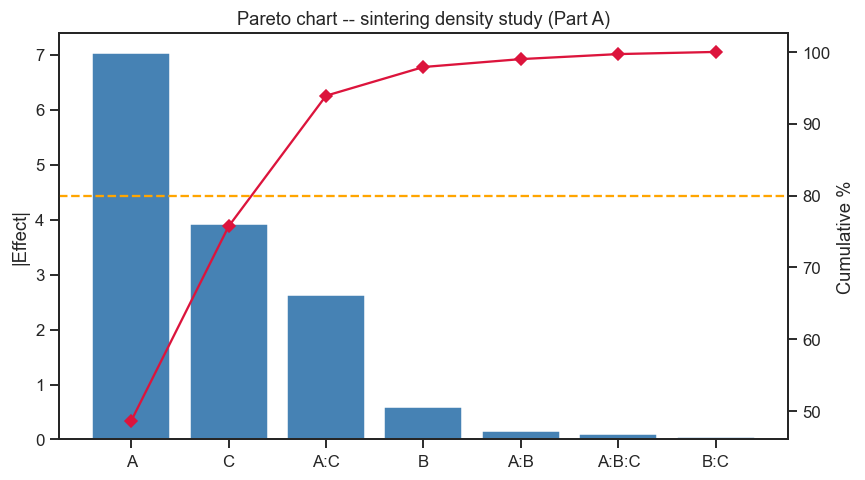

In [9]:
effects = (2 * mod_full.params.drop('Intercept')).abs().sort_values(ascending=False)
effects_df = effects.to_frame('abs_effect')
effects_df['cum_pct'] = (effects_df['abs_effect'].cumsum()
                          / effects_df['abs_effect'].sum() * 100).round(1)
print(effects_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(effects_df.index, effects_df['abs_effect'], color='steelblue')
ax2 = ax.twinx()
ax2.plot(effects_df.index, effects_df['cum_pct'], color='crimson', marker='D')
ax2.axhline(80, color='orange', linestyle='dashed')
ax.set_ylabel('|Effect|'); ax2.set_ylabel('Cumulative %')
ax.set_title('Pareto chart -- sintering density study (Part A)')
plt.tight_layout()
plt.show()

:::{admonition} Take-home message
:class: tip

`A` (dwell time, effect 7.03) and `C` (pressure, effect 3.92) together
already cover 75.7% of the cumulative effect; `A:C`
(effect 2.63) pushes that to 93.9%, and `B` (0.59) and the remaining
interactions trail far behind, together barely 6%. This matches the true
built-in structure closely — true effects of 7.0 (`A`), 4.0 (`C`), 2.4
(`A:C`), and 0.6 (`B`) — though as Section 23.3's next cell shows, "close
to the true ranking" and "clears an 80% cumulative cutoff" are not always
the same thing.
:::

In [10]:
keep_terms = effects_df[effects_df['cum_pct'] <= 80].index.tolist()
if not keep_terms:                      # always keep at least the single largest term
    keep_terms = [effects_df.index[0]]
print('Terms kept (cumulative <= 80%):', keep_terms)

formula_reduced = 'y ~ ' + ' + '.join(keep_terms)
mod_reduced_A = smf.ols(formula_reduced, data=results).fit()
print(mod_reduced_A.summary().tables[1])

Terms kept (cumulative <= 80%): ['A', 'C']
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     92.0480      0.603    152.559      0.000      90.497      93.599
A              3.5170      0.603      5.829      0.002       1.966       5.068
C              1.9595      0.603      3.248      0.023       0.409       3.510


:::{admonition} Take-home message
:class: tip

The mechanical 80%-cumulative rule keeps only `A` and `C` here — `A:C`'s
cumulative total (93.9%) falls just past the 80% line, so a strict
cutoff drops a genuinely real interaction (true effect 2.4) purely
because of where the cumulative percentage happened to cross 80% after
`C`. The 2-term reduced model still fits well (R²=0.899) and both
coefficients land close to true (`A`: fitted 3.517 vs. true 3.5; `C`:
fitted 1.960 vs. true 2.0), so this isn't a *bad* model — but it is a
reminder that an 80% cumulative threshold, like any rule of thumb, is a
starting point for judgement, not a substitute for it. A Minitab analyst
eyeballing the same chart, seeing the clear gap between `A:C` and `B`,
would likely have kept `A:C` too. And when replicates exist, a real test
beats both: the 40-pellet fit in Section 23.2 flags `A:C` (and even the
small `B`) at p < 0.0001.
:::

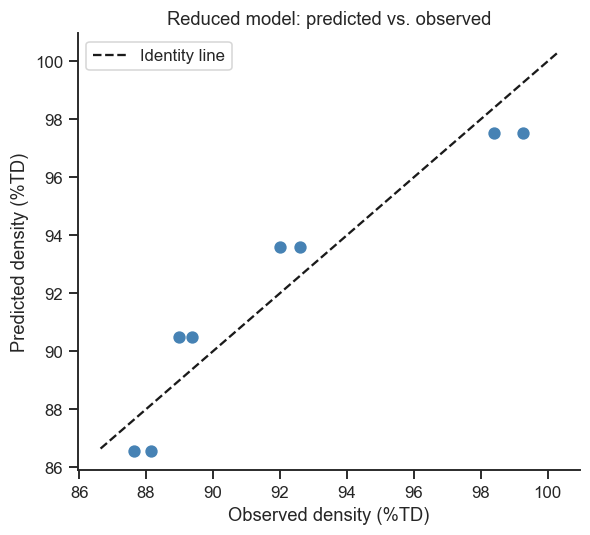

Reduced model R2 = 0.8990


In [11]:
results['y_pred'] = mod_reduced_A.predict(results)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(results['y'], results['y_pred'], color='steelblue', s=50)
lims = [results['y'].min() - 1, results['y'].max() + 1]
ax.plot(lims, lims, 'k--', label='Identity line')
ax.set_xlabel('Observed density (%TD)'); ax.set_ylabel('Predicted density (%TD)')
ax.set_title('Reduced model: predicted vs. observed'); ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print(f'Reduced model R2 = {mod_reduced_A.rsquared:.4f}')

**Checkpoint**: does `keep_terms` recover `A` and `C` — the two largest
terms built into `true_density`? Then look at the two smaller terms that
are also built in, `A:C` and `B`: where do they fall relative to the 80%
cumulative line, and does that match what you'd have chosen by eye from the
Pareto chart — or what the 40-pellet fit in Section 23.2 says? This is the
same reduction logic as Notebook 24 (Live Tutorial 3) §24.2, just driven by
effect magnitude instead of a p-value, because the averages alone carry no
p-values.

## 23.4 Raising the Stakes: Box & Draper's Dyestuff Study

Part A was small and synthetic — 8 corners, 3 factors, invented numbers.
Part B uses **genuine published data** from Box & Draper's *Empirical
Model-Building and Response Surfaces* (Wiley, 1987), Chapter 4 (p. 115):
the manufacture of a **dyestuff**. The chemistry of the process was not
well understood, so instead of a mechanistic model the investigators ran
an empirical study — a full $2^6$ factorial, 64 runs:

| Coded factor | Process variable | Low (−1) | High (+1) |
|---|---|---|---|
| x1 | Polysulfide index | 6 | 7 |
| x2 | Reflux rate | 150 | 170 |
| x3 | Moles of polysulfide | 1.8 | 1.4 |
| x4 | Time | 24 | 36 |
| x5 | Amount of solvent | 30 | 42 |
| x6 | Temperature | 120 | 130 |

The levels are as quoted in the source, which gives no units. Note that
for $x_3$ the + level is the *smaller* amount: coding only needs one level
labelled + and the other −.

Three properties of the dye were measured in every run: **$y_1$ =
strength, $y_2$ = hue, $y_3$ = brightness**. We work with strength ($y_1$)
throughout this section (Exercise 2 asks you to repeat the analysis for hue
or brightness). The same two techniques from Part A — manual
contrast-based effects and a `statsmodels` OLS fit — scale up completely
unchanged; only the *practicality* of writing out the model formula by
hand changes, which is exactly the problem Section 23.6 solves. Unlike
Part A, this design is **unreplicated**: one run per corner, so there is
no pure error at all.

In [12]:
encoded_inputs6 = list(product([-1, 1], [-1, 1], [-1, 1], [-1, 1], [-1, 1], [-1, 1]))
doe = pd.DataFrame(encoded_inputs6)
doe = doe[doe.columns[::-1]]
doe.columns = [f'x{i+1}' for i in range(6)]

# Real published data: Box & Draper (1987), Ch. 4 -- a dyestuff process.
# y1 = strength, y2 = hue, y3 = brightness, recorded from the same 64-run 2^6 design.
doe['y1'] = [3.4, 9.7, 7.4, 10.6, 6.5, 7.9, 10.3, 9.5, 14.3, 10.5, 7.8, 17.2, 9.4, 12.1, 9.5, 15.8, 8.3, 8.0, 7.9, 10.7, 7.2, 7.2, 7.9, 10.2, 10.3, 9.9, 7.4, 10.5, 9.6, 15.1, 8.7, 12.1, 12.6, 10.5, 11.3, 10.6, 8.1, 12.5, 11.1, 12.9, 14.6, 12.7, 10.8, 17.1, 13.6, 14.6, 13.3, 14.4, 11.0, 12.5, 8.9, 13.1, 7.6, 8.6, 11.8, 12.4, 13.4, 14.6, 14.9, 11.8, 15.6, 12.8, 13.5, 15.8]
doe['y2'] = [15,5,23, 8,20, 9, 13, 5, 23, 1, 11, 5, 15, 8, 15, 1, 22, 8, 16, 7, 25, 5, 17, 8, 10, 3, 22, 6, 24, 4, 10, 5, 32, 10, 28, 18, 22, 31, 17, 16, 38, 12, 34, 19, 12, 14, 25, 16, 31, 14, 23, 23, 28, 20, 18, 11, 39, 30, 31, 6, 33, 23, 31, 11]
doe['y3'] = [36, 35, 37, 34, 30, 32, 28, 38, 40, 32, 32, 28, 34, 26,  30, 28, 40, 30, 35, 35, 32, 35, 36, 32, 20, 35, 35, 28, 27, 36, 36, 35, 32, 34, 30, 24, 30, 20, 32, 25, 20, 20, 22, 35, 26, 15, 19, 24, 22, 23, 22, 18, 20, 20, 20, 36, 20, 11, 20, 35, 16, 32, 20, 20]
print(f'{len(doe)} runs, 6 factors, 3 responses: y1 = strength, y2 = hue, y3 = brightness.')
doe[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y1', 'y2', 'y3']].head()

64 runs, 6 factors, 3 responses: y1 = strength, y2 = hue, y3 = brightness.


,x1,x2,x3,x4,x5,x6,y1,y2,y3
0,-1,-1,-1,-1,-1,-1,3.4,15,36
1,1,-1,-1,-1,-1,-1,9.7,5,35
2,-1,1,-1,-1,-1,-1,7.4,23,37
3,1,1,-1,-1,-1,-1,10.6,8,34
4,-1,-1,1,-1,-1,-1,6.5,20,30


## 23.5 Computing Effects by Hand — Contrasts and Yates' Algorithm

The same contrast formula from Notebook 22 §22.2 generalises cleanly to
any number of factors: for a $k$-way interaction, the "column" is simply
the elementwise product of the $k$ individual coded columns, and the
effect is that contrast divided by $n/2$ ($n=64$ runs here, all of them
corners, so $n/2=32$).

In [13]:
labels = {1: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']}
for k in [2, 3, 4, 5, 6]:
    labels[k] = list(combinations(labels[1], k))

effects_y1 = {}
for k in [1, 2, 3, 4, 5, 6]:
    for combo in labels[k]:
        factors = (combo,) if k == 1 else combo   # k=1 entries are bare strings, not tuples
        sign = np.prod([doe[f] for f in factors], axis=0)
        effects_y1[combo] = (sign * doe['y1']).sum() / 32   # n/2 = 64/2 = 32

effects_series = pd.Series(effects_y1)
print(f'{len(effects_series)} effects computed by hand for y1 '
      f'(main effects through the 6-way interaction, 2^6 - 1 = 63 terms).')
print(effects_series.abs().sort_values(ascending=False).head(10))

63 effects computed by hand for y1 (main effects through the 6-way interaction, 2^6 - 1 = 63 terms).
x4                      2.984375
x6                      2.690625
x1                      1.746875
(x1, x2, x4, x5)        1.159375
(x1, x2)                0.890625
(x2, x4)                0.859375
(x1, x6)                0.821875
(x1, x2, x4)            0.815625
(x1, x3, x4, x6)        0.765625
(x1, x2, x3, x4, x6)    0.740625
dtype: float64


### Yates' algorithm: the same contrasts from sums and differences

Before computers, nobody built 63 sign columns. **Yates' algorithm**
(Yates, 1937) produces every contrast at once, with nothing but pairwise
sums and differences. It rests on one observation: in **standard order**
(the first factor flips fastest — which is why the data cell above
reversed the column order), neighbouring runs 1 & 2, 3 & 4, … differ in
the first factor only. So for each pair of neighbours, the **sum** averages
that factor out, and the **difference** (second − first) is that factor's
effect, at the levels the other factors have in that pair. For $k$
factors, repeat $k$ times:

1. take the column in pairs: (1st, 2nd), (3rd, 4th), …;
2. top half of the new column: the **sums** of the pairs;
3. bottom half: the **differences**, second minus first.

Stacking the sums above the differences makes the *new* neighbours differ
only in the next factor, so the same move works again.

**A worked example.** Take a $2^2$ design in standard order — runs (−,−),
(+,−), (−,+), (+,+) — with responses $y$ = 20, 40, 30, 70. *Pass 1* pairs
runs 1 & 2 (both B low) and runs 3 & 4 (both B high), so only A changes
within a pair:

| New value | Calculation | Meaning |
|---|---|---|
| 60 | 20 + 40 | total at B low |
| 100 | 30 + 70 | total at B high |
| 20 | 40 − 20 | effect of A at B low |
| 40 | 70 − 30 | effect of A at B high |

*Pass 2* pairs (60, 100) and (20, 40), which differ only in B:

| New value | Calculation | Meaning | Contrast of |
|---|---|---|---|
| 160 | 60 + 100 | grand total | I |
| 60 | 20 + 40 | A's effect at B low + at B high | A |
| 40 | 100 − 60 | total at B high − total at B low | B |
| 20 | 40 − 20 | A's effect at B high − at B low | AB |

Dividing by $n = 4$ (for I) or $n/2 = 2$ (for the rest) gives the average
40 and the effects A = 30, B = 20, AB = 10 — the same as the contrast
method. Pass 1 found A's effect at each level of B; pass 2 *added* them
(the main effect) and *subtracted* them (the interaction: half the change
in A's effect between the levels of B), done mechanically.

**Which entry is which?** An entry contains a factor if it took a
*difference* in that factor's pass: A is a difference in pass 1 only, B in
pass 2 only, AB in both. In general, number the positions from 0 and write
them in binary; the 1-bits name the factors (last bit = first factor).
With six factors, position 3 = 000011 → x1:x2 and position 8 = 001000 →
x4. The column therefore always comes out in standard order: I, A, B, AB,
C, AC, BC, ABC, …

**A second example, three factors.** Pilot-plant yield (Box, Hunter &
Hunter; A = temperature, B = concentration, C = catalyst), 8 runs in
standard order, so 3 passes:

| A | B | C | y | Pass 1 | Pass 2 | Pass 3 | Contrast of | Effect |
|---|---|---|---|---|---|---|---|---|
| − | − | − | 60 | 132 | 254 | 514 | I | 64.25 (average) |
| + | − | − | 72 | 122 | 260 | 92 | A | 23 |
| − | + | − | 54 | 135 | 26 | −20 | B | −5 |
| + | + | − | 68 | 125 | 66 | 6 | AB | 1.5 |
| − | − | + | 52 | 12 | −10 | 6 | C | 1.5 |
| + | − | + | 83 | 14 | −10 | 40 | AC | 10 |
| − | + | + | 45 | 31 | 2 | 0 | BC | 0 |
| + | + | + | 80 | 35 | 4 | 2 | ABC | 0.5 |

The bottom half of pass 1 (12, 14, 31, 35) is the effect of temperature at
each combination of concentration and catalyst. It is much larger with the
catalyst high (31, 35) than low (12, 14): that is the large AC interaction
(10), visible already after the first pass.

The next two cells write the algorithm as a small function, test it on the
$2^2$ example, and then run the six passes for the 64 runs of $y_1$.

In [14]:
def yates(y, show=False):
    # Yates' algorithm: k passes of pairwise sums (top half) and differences (bottom half)
    col = np.asarray(y, dtype=float)
    k = int(np.log2(len(col)))                           # number of factors = number of passes
    for p in range(k):
        pairs = col.reshape(-1, 2)                       # (1st, 2nd), (3rd, 4th), ...
        col = np.concatenate([pairs.sum(axis=1),         # top half: sums
                              pairs[:, 1] - pairs[:, 0]])# bottom half: second minus first
        if show:
            print(f'pass {p + 1}:', col)
    return col

# Test on the 2^2 worked example first: it must end with 160, 60, 40, 20
contrasts_toy = yates([20, 40, 30, 70], show=True)

pass 1: [ 60. 100.  20.  40.]
pass 2: [160.  60.  40.  20.]


In [15]:
contrasts = yates(doe['y1'])                          # 64 responses in standard order -> 6 passes

# Position i holds the term whose factors are the 1-bits of i (e.g. 3 = 000011 -> x1:x2)
names = ['I'] + [':'.join(f'x{j+1}' for j in range(6) if (i >> j) & 1) for i in range(1, 64)]
yates_effects = pd.Series(contrasts[1:] / 32, index=names[1:])   # effect = contrast / (n/2)

contrast_effects = pd.Series({(':'.join(k) if isinstance(k, tuple) else k): v
                              for k, v in effects_y1.items()})
print(f'Average from Yates (I / 64): {contrasts[0] / 64:.4f}')
print('Yates effects identical to the contrast method for all 63 terms:',
      np.allclose(yates_effects, contrast_effects.reindex(yates_effects.index)))

Average from Yates (I / 64): 11.1234
Yates effects identical to the contrast method for all 63 terms: True


## 23.6 The Same Effects, Automatically — statsmodels OLS

Writing a 63-term formula string by hand for 6 factors is not realistic —
this is precisely where a Minitab-style point-and-click tool starts to
look genuinely convenient, and precisely where a few lines of Python that
*generate* the formula string win the comparison back.

In [16]:
terms = [combo if isinstance(combo, str) else ':'.join(combo)
         for k in [1, 2, 3, 4, 5, 6] for combo in labels[k]]
formula_full6 = 'y1 ~ ' + ' + '.join(terms)
print(f'{len(terms)} terms in the auto-generated formula '
      f'(2^6 - 1 = 63, matching the effects computed by hand above).')

mod_y1 = smf.ols(formula_full6, data=doe).fit()
print(f'Residual df: {int(mod_y1.df_resid)}  (64 runs - 64 parameters -- '
      'the same zero-df situation as Part A, at 8x the scale.)')

63 terms in the auto-generated formula (2^6 - 1 = 63, matching the effects computed by hand above).
Residual df: 0  (64 runs - 64 parameters -- the same zero-df situation as Part A, at 8x the scale.)


In [17]:
ols_effects = (2 * mod_y1.params.drop('Intercept')).abs()

# Match manual-effect names (tuples for multi-factor terms) to statsmodels' 'x1:x2' keys
manual_named = effects_series.abs()
manual_named.index = [':'.join(k) if isinstance(k, tuple) else k for k in manual_named.index]

compare = pd.DataFrame({'by_hand': manual_named, 'statsmodels_2xOLS': ols_effects})
compare = compare.sort_values('by_hand', ascending=False)
print(compare.head(8).round(4))
print(f'\nMax absolute difference across all 63 effects: '
      f'{(compare["by_hand"] - compare["statsmodels_2xOLS"]).abs().max():.6f}')

             by_hand  statsmodels_2xOLS
x4            2.9844             2.9844
x6            2.6906             2.6906
x1            1.7469             1.7469
x1:x2:x4:x5   1.1594             1.1594
x1:x2         0.8906             0.8906
x2:x4         0.8594             0.8594
x1:x6         0.8219             0.8219
x1:x2:x4      0.8156             0.8156

Max absolute difference across all 63 effects: 0.000000


:::{admonition} Take-home message
:class: tip

The hand-computed effects (contrast method or Yates' algorithm) and the
`2 × statsmodels` coefficients agree to
**0.000000** across all 63 terms — not "close," identical to floating-point
precision. This is Notebook 22 §22.2's checkpoint again, now demonstrated
at 6 factors and 63 terms instead of 2 factors and 3: a factorial effect
is a regression coefficient in different units, full stop, regardless of
how many factors are involved or which method computed it first.
:::

## 23.7 Screening Without Replication: Pareto and Normal-Probability Plots

With 64 unreplicated runs and 63 possible effects, there is no pure-error
degrees of freedom for a formal F-test — the same zero-df situation as
Section 23.2, just at 8× the scale, and now with far too many bars for a
Pareto chart alone to read comfortably. The **normal-probability (QQ)
plot** solves this: if every effect were pure noise, the sorted effects
would fall on a straight line against their theoretical normal quantiles;
genuinely active effects break away from that line.

Keep the **sign** of each effect for this plot. Noise effects scatter
symmetrically around zero, so real positive effects break away at the top
right and real negative ones at the bottom left. (Lecture 4's half-normal
plot uses |effect| instead, against half-normal quantiles.) The reference
line is drawn through the quartiles — the middle half of the effects,
where the noise lives — so the few large effects cannot pull it towards
themselves.

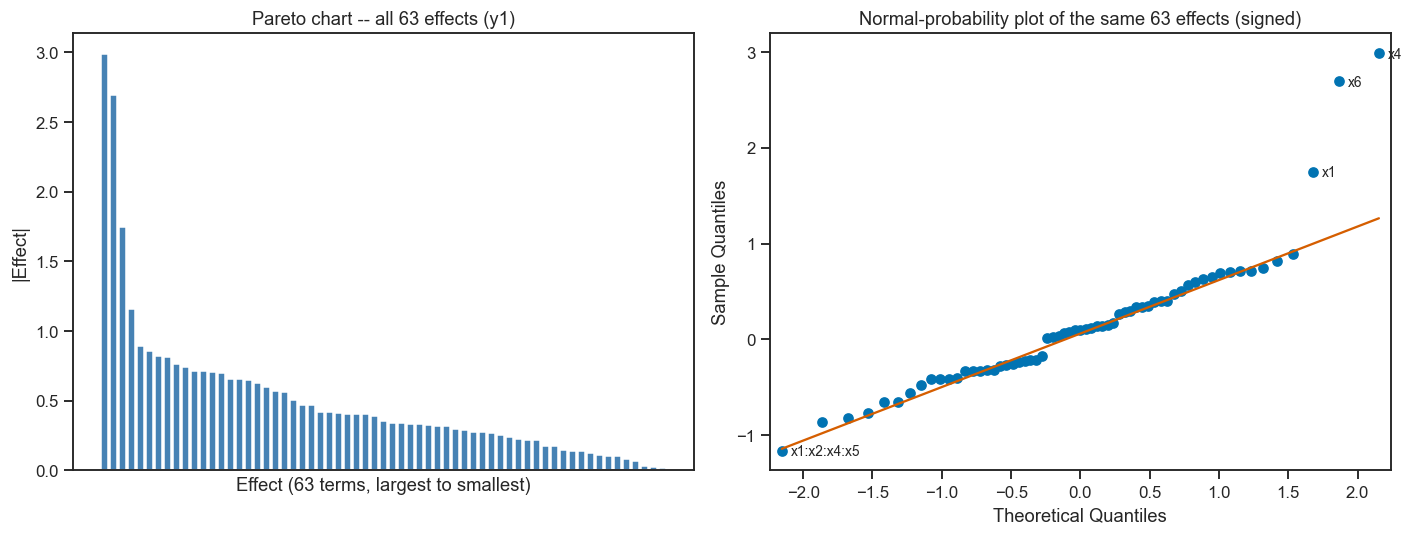

Largest 6 effects by size (with sign):
x4             2.984
x6             2.691
x1             1.747
x1:x2:x4:x5   -1.159
x1:x2          0.891
x2:x4         -0.859
dtype: float64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sorted_effects = ols_effects.sort_values(ascending=False)          # |effects|, largest first
axes[0].bar(range(len(sorted_effects)), sorted_effects.values, color='steelblue')
axes[0].set_xticks([])
axes[0].set_xlabel('Effect (63 terms, largest to smallest)')
axes[0].set_ylabel('|Effect|')
axes[0].set_title('Pareto chart -- all 63 effects (y1)')

signed_effects = 2 * mod_y1.params.drop('Intercept')               # keep the sign for a normal plot
pp = smg.ProbPlot(signed_effects.values)
pp.qqplot(line='q', ax=axes[1])                                     # line through the quartiles
for q, v, name in zip(pp.theoretical_quantiles, pp.sorted_data, signed_effects.sort_values().index):
    if abs(v) > 1.0:                                                # label only the largest few
        axes[1].annotate(name, (q, v), xytext=(6, -3), textcoords='offset points', fontsize=9)
axes[1].set_title('Normal-probability plot of the same 63 effects (signed)')

plt.tight_layout()
plt.show()

print('Largest 6 effects by size (with sign):')
print(signed_effects.reindex(signed_effects.abs().sort_values(ascending=False).index).head(6).round(3))

**Checkpoint**: which effects visibly break away from the straight line
of small, noise-like effects bunched near the origin of the
normal-probability plot? Keep your answer in mind for Section 23.8.

:::{admonition} Take-home message
:class: tip

The three largest effects on strength — `x4` time (+2.98), `x6`
temperature (+2.69), `x1` polysulfide index (+1.75) —
break away at the top right, and they are exactly the three terms Box &
Draper's own analysis singles out (Section 23.8). The Pareto chart alone is
ambiguous: the fourth bar, `x1:x2:x4:x5` (1.16), is a 4-way interaction
bigger than several 2-way interactions further down, and the bars shrink
gradually from there (0.89, 0.86, 0.82, ...). The normal plot settles it:
with its sign (−1.16), that effect sits right on the line at the bottom
left, just where the most negative of 63 noise effects belongs — and real
high-order interactions are rare anyway (*effect sparsity*). Keeping the
sign is what makes the normal plot more informative than a bar chart of
sizes. It is still a judgement by eye, not a formal test, so domain
knowledge about which interactions are physically plausible remains part
of the decision.
:::

## 23.8 Reading the Result: What the Book Says

Box & Draper's own analysis of this dataset settles on three dominant
terms for strength ($y_1$): $x_1$ (polysulfide index), $x_4$ (time) and
$x_6$ (temperature), with the fitted equation
$\hat y_1 = 11.12 + 0.87\,x_1 + 1.49\,x_4 + 1.35\,x_6$. Fit that reduced
model (you should reproduce it exactly) and validate it: check its residual standard deviation two independent ways,
and look at both a predicted-vs-observed plot and a residual plot. This
checks the fit on the same 64 runs; a *confirmation* in the sense of
Notebook 22 §22.5 would need new experiments.

In [19]:
mod_final = smf.ols('y1 ~ x1 + x4 + x6', data=doe).fit()
print(mod_final.summary().tables[1])
print(f'\nResidual standard deviation: {mod_final.scale**0.5:.3f}  '
      f'(matches sqrt(sum(resid^2)/df_resid) = '
      f'{np.sqrt(np.sum(mod_final.resid**2) / mod_final.df_resid):.3f})')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.1234      0.238     46.741      0.000      10.647      11.599
x1             0.8734      0.238      3.670      0.001       0.397       1.349
x4             1.4922      0.238      6.270      0.000       1.016       1.968
x6             1.3453      0.238      5.653      0.000       0.869       1.821

Residual standard deviation: 1.904  (matches sqrt(sum(resid^2)/df_resid) = 1.904)


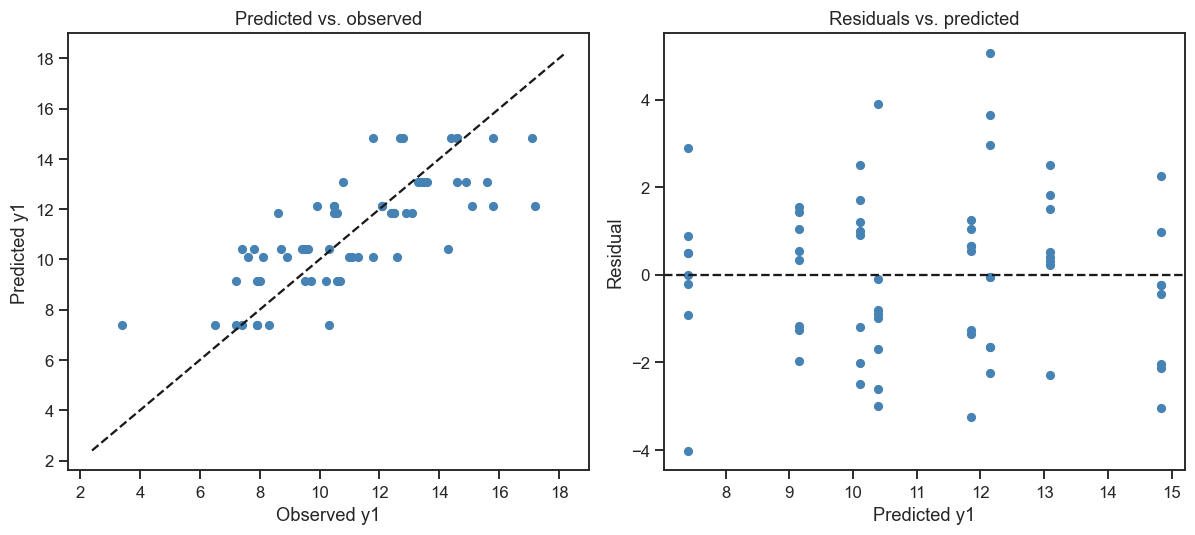

Reduced model (x1, x4, x6 only): R2=0.585, R2_adj=0.565


In [20]:
doe['y1_pred'] = mod_final.predict(doe)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(doe['y1'], doe['y1_pred'], color='steelblue', s=25)
lims = [doe['y1'].min() - 1, doe['y1'].max() + 1]
axes[0].plot(lims, lims, 'k--')
axes[0].set_xlabel('Observed y1'); axes[0].set_ylabel('Predicted y1')
axes[0].set_title('Predicted vs. observed')

axes[1].scatter(doe['y1_pred'], mod_final.resid, color='steelblue', s=25)
axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_xlabel('Predicted y1'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs. predicted')

plt.tight_layout()
plt.show()

print(f'Reduced model (x1, x4, x6 only): R2={mod_final.rsquared:.3f}, '
      f'R2_adj={mod_final.rsquared_adj:.3f}')

:::{admonition} Take-home message
:class: tip

All three terms are significant (p≤0.001) and each fitted coefficient is
exactly half its Section 23.5/23.6 effect — `x1`: 0.873 (effect 1.747),
`x4`: 1.492 (effect 2.984), `x6`: 1.345 (effect 2.691) — the same
coefficient-equals-half-the-effect relationship checked in every factorial
notebook so far. In words: **time, temperature and polysulfide index all
make the dye stronger**, with time mattering most. With only 3 of 63
possible terms, the model explains a
real but modest 58.5% of the variance in $y_1$ (R²_adj=0.565) and has a
residual standard deviation of 1.90 against $y_1$ values ranging roughly
3–17 — a genuinely useful screening result on real data, not a
picture-perfect fit, which is an honest note to end on: real published
data rarely reduces as cleanly as a synthetic teaching example does.
:::

---
## Exercises

**Core practice**

1. **A different dominant factor**: Redo Part A (Sections 23.1–23.3) with
   a different `true_density` — make `B` (temperature) the dominant term
   instead of `A`, and remove the `A:C` interaction. Confirm the Pareto
   chart and the automatic 80%-cumulative reduction correctly identify the
   new dominant factor.

2. **Repeat for hue ($y_2$) or brightness ($y_3$)**: Redo Sections
   23.5–23.8 for one of the other two responses of the dyestuff study. Which of $x_1,\ldots,x_6$
   turn out to matter for that response, and how much overlap is there
   with the terms that mattered for $y_1$?

**Deeper practice**

3. **When does the formula-generation trick stop being optional?**
   Section 23.6's auto-generated formula has 63 terms for 6 factors.
   Work out how many terms a full factorial model would need for 8
   factors, and for 10 — at what point does writing the formula by hand
   go from "tedious but possible" to "not realistically possible without
   a bug"?

4. **A fractional alternative**: Fit a Resolution IV half-fraction
   (`pyDOE3.fracfact`, Notebook 18) of the 6-factor design instead of the
   full 64 runs, using only the 32 runs it selects. Is the reduced model
   from Section 23.8 ($x_1$, $x_4$, $x_6$) still recoverable, and what
   happens to any of those three terms that turn out to be aliased with
   each other on the half-fraction?